## Data preparation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
# data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [3]:
# !wget $data -O data-churn.csv

In [4]:
df = pd.read_csv('data-churn.csv')
#df.head()

In [5]:
#df.head().T

In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)
#categorical_columns

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ','_')

In [7]:
#df.head().T

In [8]:
#df.dtypes

total charges is meant to be a number

In [9]:
#df.totalcharges

In [10]:
# convert object to number
tc = pd.to_numeric(df.totalcharges, errors = 'coerce')
tc.isnull().sum()

np.int64(11)

In [11]:
#df[tc.isnull()][['customerid', 'totalcharges']]

In [12]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors = 'coerce')

In [13]:
# fill nan with zeros
df.totalcharges = df.totalcharges.fillna(0)

In [14]:
df.churn

0        no
1        no
2       yes
3        no
4       yes
       ... 
7038     no
7039     no
7040     no
7041    yes
7042     no
Name: churn, Length: 7043, dtype: object

In [15]:
# convert the churn variable to zero and one
(df.churn == 'yes').astype(int).head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

In [16]:
df.churn = (df.churn == 'yes').astype(int)

## Setting up the validation framework
Perform the train/validation/test split with scikit-learn

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
#train_test_split?

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state = 1)

In [19]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state = 1)

In [20]:
len(df_train), len(df_test), len(df_val)

(4225, 1409, 1409)

In [21]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [22]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [23]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [24]:
# df_train.head().T

## EDA
for this we use the df_full_train dataset

In [25]:
df_full_train = df_full_train.reset_index(drop = True)

In [26]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [27]:
df_full_train.churn.value_counts()

churn
0    4113
1    1521
Name: count, dtype: int64

In [28]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

churn rate = 0.269968

In [29]:
global_churn_rate = df_full_train.churn.mean()
print(round(global_churn_rate, 2))

0.27


In [30]:
df_full_train.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [31]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [32]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [33]:
categorical = [ 'gender', 'seniorcitizen', 'partner', 'dependents',
        'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

In [34]:
df_full_train[categorical]

,gender,seniorcitizen,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod
0,male,0,yes,yes,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check
1,female,0,no,no,yes,no,dsl,yes,yes,yes,yes,no,yes,one_year,no,credit_card_(automatic)
2,male,0,yes,no,yes,yes,dsl,yes,yes,no,yes,no,no,two_year,no,bank_transfer_(automatic)
3,male,0,yes,yes,yes,yes,dsl,yes,no,yes,yes,yes,yes,one_year,no,electronic_check
4,male,0,no,no,yes,no,dsl,yes,yes,no,yes,yes,no,one_year,no,electronic_check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,male,1,no,no,yes,yes,fiber_optic,no,no,yes,no,yes,yes,month-to-month,yes,electronic_check
5630,male,0,no,yes,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check
5631,male,0,no,no,yes,yes,fiber_optic,no,yes,yes,no,yes,yes,month-to-month,yes,electronic_check
5632,male,0,no,no,yes,yes,dsl,no,yes,no,no,no,no,month-to-month,yes,mailed_check


In [35]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## Feature importance: churn rate and risk ratio

### churn rate in different groups of variables

In [36]:
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
print(churn_female)

0.27682403433476394


In [37]:
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()
print(churn_male)

0.2632135306553911


In [38]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
print(churn_partner)

0.20503330866025166


In [39]:
churn_nopartner = df_full_train[df_full_train.partner == 'no'].churn.mean()
print(churn_nopartner)

0.3298090040927694


In [40]:
global_churn_rate = df_full_train.churn.mean()
print(round(global_churn_rate, 2))

0.27


In [41]:
global_churn_rate - churn_nopartner

np.float64(-0.05984095297455855)

more likely to churn

### Risk Ratio

greater than 1 more like to churn and less than 1 less likely to churn

In [42]:
churn_nopartner / global_churn_rate # more likely to churn

np.float64(1.2216593879412643)

In [43]:
churn_partner / global_churn_rate

np.float64(0.7594724924338315)

In [44]:
churn_male / global_churn_rate

np.float64(0.9749802969838747)

In [45]:
churn_female / global_churn_rate

np.float64(1.0253955354648652)

#### To do this for all the categorical variables

In [46]:
from IPython.display import display

In [47]:
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn_rate
    df_group['risk'] = df_group['mean'] / global_churn_rate
    display(df_group)
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


## Feature importance: mutual information
Mutual information is a concept in information theory that tell us how much we can learn about one variable if we know the value of another variable. Its a measure of dependence between two variables

In [48]:
from sklearn.metrics import mutual_info_score

In [49]:
mutual_info_score(df_full_train.churn, df_full_train.contract)

np.float64(0.0983203874041556)

In [50]:
mutual_info_score(df_full_train.churn, df_full_train.gender)

np.float64(0.0001174846211139946)

In [51]:
mutual_info_score(df_full_train.churn, df_full_train.partner)

np.float64(0.009967689095399745)

In [52]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [53]:
 mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending = False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

## Feature importance: correlation

In [54]:
df_full_train[numerical].head()

,tenure,monthlycharges,totalcharges
0,12,19.70,258.35
1,42,73.90,3160.55
2,71,65.15,4681.75
3,71,85.45,6300.85
4,30,70.40,2044.75


In [55]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [56]:
df_full_train[numerical].corrwith(df_full_train.churn).abs()

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

### One-hot encoding

In [57]:
from sklearn.feature_extraction import DictVectorizer

In [58]:
#df_train[['gender', 'contract']].iloc[:10]

In [59]:
train_dicts = df_train[categorical + numerical].to_dict(orient = 'records')
#train_dicts

In [60]:
dv = DictVectorizer(sparse = False)

In [61]:
X_train = dv.fit_transform(train_dicts)

In [62]:
val_dicts = df_val[categorical + numerical].to_dict(orient = 'records')

In [63]:
X_val = dv.transform(val_dicts)

## Training logistic regression
Binary classification

In [64]:
from sklearn.linear_model import LogisticRegression

In [65]:
model = LogisticRegression(max_iter = 10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [66]:
model.intercept_[0]

np.float64(-0.05046949215469961)

In [67]:
model.coef_[0].round(3)

array([ 0.683,  0.039, -0.69 ,  0.051, -0.02 ,  0.11 , -0.157,  0.079,
        0.035, -0.004, -0.488,  0.677, -0.157, -0.017, -0.191,  0.069,
        0.153,  0.114, -0.157,  0.075,  0.282, -0.157, -0.093, -0.166,
        0.198, -0.048,  0.08 , -0.054, -0.006,  0.105, -0.014,  0.069,
       -0.038,  0.193, -0.095, -0.157,  0.284, -0.055, -0.157,  0.244,
        0.231, -0.157, -0.043, -0.069,  0.   ])

In [68]:
# Hard predictions
model.predict(X_train)

array([0, 1, 1, ..., 1, 0, 1], shape=(4225,))

In [69]:
# soft predictions
model.predict_proba(X_train)

array([[0.92760156, 0.07239844],
       [0.32405706, 0.67594294],
       [0.3691961 , 0.6308039 ],
       ...,
       [0.4886866 , 0.5113134 ],
       [0.97474422, 0.02525578],
       [0.30633972, 0.69366028]], shape=(4225, 2))

In [70]:
# probability of churining in training dataset
# y_pred = model.predict_proba(X_train)[:,1]

In [71]:
# probability of churining in training dataset
y_pred = model.predict_proba(X_val)[:,1]
y_pred

array([0.0065992 , 0.20460328, 0.21756488, ..., 0.15176934, 0.78824497,
       0.81184088], shape=(1409,))

In [72]:
churn_decision = (y_pred >= 0.5)
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [73]:
#df_val[churn_decision].customerid

In [74]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [75]:
y_val

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [76]:
# check the number of match predictions
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

In [77]:
# df_pred = pd.DataFrame()
# df_pred['probability'] = y_pred
# df_pred['prediction'] = churn_decision.astype(int)
# df_pred['actual'] = y_val
# df_pred['correct'] = (df_pred.prediction == df_pred.actual)
# df_pred

In [78]:
# df_pred.correct.mean()

## Model intepretation

In [79]:
dict_coef = dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

In [80]:
clean_dict_coef = {key: float(value) for key, value in dict_coef.items()}
#clean_dict_coef

In [81]:
# Train a smaller model
small = ['contract', 'tenure', 'monthlycharges']

In [82]:
dict_train_small = df_train[small].to_dict(orient = 'records')
dict_val_small = df_val[small].to_dict(orient = 'records')

In [83]:
dv_small = DictVectorizer(sparse = False)

In [84]:
dv_small.fit(dict_train_small)

DictVectorizer(sparse=False)

In [85]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [86]:
X_train_small = dv_small.transform(dict_train_small)

In [87]:
model_small = LogisticRegression()

In [88]:
model_small.fit(X_train_small, y_train)

LogisticRegression()

In [89]:
w0 = print(model_small.intercept_[0])

-2.477957595766546


In [90]:
w = model_small.coef_[0]
w.round(3)

array([ 0.971, -0.024, -0.948,  0.027, -0.036])

In [91]:
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

{'contract=month-to-month': np.float64(0.971),
 'contract=one_year': np.float64(-0.024),
 'contract=two_year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

In [92]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
z = np.linspace(-7, 7, 51)
sigmoid(10000)

np.float64(1.0)

In [93]:
-2.477957595766546 + 0.971 + 50 * 0.027 + 5 * (-0.036)

-0.33695759576654566

In [94]:
sigmoid(_)

np.float64(0.4165487022035306)

In [95]:
-2.47 + 0.97 + 60 * 0.027 + 1 * (-0.036)

0.08399999999999966

In [96]:
sigmoid(_)

np.float64(0.5209876607065322)

In [97]:
-2.47 + (-0.949) + 30 * 0.027 + 24 * (-0.036)

-3.473

In [98]:
sigmoid(_)

np.float64(0.030090303318277657)

## Using the model

In [99]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient = 'records')
#dicts_full_train[:3]

In [100]:
dv = DictVectorizer(sparse = False)
X_full_train = dv.fit_transform(dicts_full_train)

In [101]:
y_full_train = df_full_train.churn.values

In [102]:
model = LogisticRegression(max_iter = 10000)
model.fit(X_full_train, y_full_train)

LogisticRegression(max_iter=10000)

In [103]:
dicts_test = df_test[categorical + numerical].to_dict(orient = 'records')

In [104]:
X_test = dv.fit_transform(dicts_test)

In [105]:
y_pred = model.predict_proba(X_test)[:,1]
y_pred

array([0.06735891, 0.09836471, 0.33433647, ..., 0.00510388, 0.20531654,
       0.63808322], shape=(1409,))

In [106]:
churn_decision = (y_pred >= 0.5)

In [107]:
(churn_decision == y_test).mean()

np.float64(0.8105039034776437)

In [108]:
# customer = dicts_test[10]
customer = dicts_test[-1]
#customer

In [109]:
X_small = dv.transform([customer])

In [110]:
model.predict_proba(X_small)[0,1]

np.float64(0.638083217691608)

In [111]:
y_test[-1]

np.int64(1)

## Accuracy and dummy model

In [112]:
len(y_val)

1409

In [113]:
(churn_decision == y_val).sum()

np.int64(868)

In [114]:
# calculate accuracy
(churn_decision == y_val).sum() / len(y_val)

np.float64(0.6160397444996452)

In [115]:
from sklearn.metrics import accuracy_score

In [116]:
accuracy_score(y_test, y_pred >= 0.5)

0.8105039034776437

In [117]:
thresholds = np.linspace(0, 1, 21)

scores = []

for t in thresholds:
    churn_decision = (y_test >= t)
    score = (y_test == churn_decision).mean()
    print('%.2f %.3f' % (t, score))
    scores.append(score)

0.00 0.247
0.05 1.000
0.10 1.000
0.15 1.000
0.20 1.000
0.25 1.000
0.30 1.000
0.35 1.000
0.40 1.000
0.45 1.000
0.50 1.000
0.55 1.000
0.60 1.000
0.65 1.000
0.70 1.000
0.75 1.000
0.80 1.000
0.85 1.000
0.90 1.000
0.95 1.000
1.00 1.000


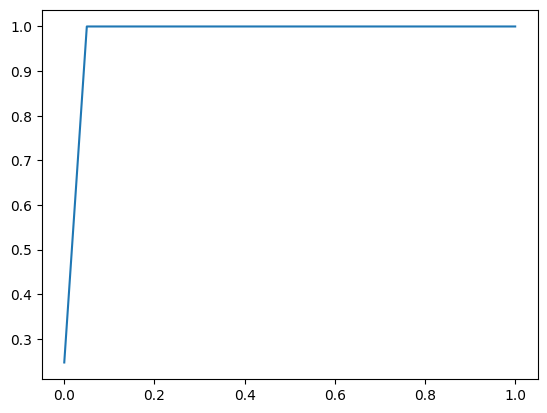

In [118]:
plt.plot(thresholds, scores)

## Confusion table

In [140]:
actual_positive = (y_test == 1)
actual_negative = (y_test == 0)

In [141]:
t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

In [142]:
tn = (actual_negative & predict_negative).sum()

In [143]:
tp = (predict_positive & actual_positive).sum()

In [144]:
fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

In [145]:
print(tp, tn, fp, fn)

204 938 123 144


In [146]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
confusion_matrix

array([[938, 123],
       [144, 204]])

In [147]:
(confusion_matrix / confusion_matrix.sum()).round(2)


array([[0.67, 0.09],
       [0.1 , 0.14]])

## Precision and Recall
> Precision is the fraction of positive predictions that are correct
> Recall is the fraction of correctly identified positives

In [153]:
accuracy  = (tp + tn) / (tp + tn + fp + fn)
print(accuracy)

0.8105039034776437


In [154]:
precision = tp / (tp + fp)
print(precision)

0.6238532110091743


In [155]:
recall = tp / (tp + fn)
print(recall)

0.5862068965517241


## ROC curves
> TPR and FPR